# S13.- Pronósticos y predicciones

La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.

Los indicadores de pérdida varían de un campo a otro. Si un usuario o una usuaria compra en una tienda en línea con poca frecuencia, pero con regularidad, no se puede decir que ha huido. Pero si durante dos semanas no ha abierto un canal que se actualiza a diario, es motivo de preocupación: es posible que tu seguidor o seguidor/a se haya aburrido y te haya abandonado.

En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

### Objetivos:

- Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
- Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
- Analizar los factores que más impactan la pérdida.
- Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente respecto a:
    - Identificar a los grupos objetivo;
    - Sugerir medidas para reducir la rotación;
    - Describir cualquier otro patrón que observes con respecto a la interacción con los clientes.

In [25]:
# Importación de librerías 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [26]:
# Leer datos
file_path = "C:/Git/vehicles_env/datasets/gym_churn_us.csv"
gym = pd.read_csv(file_path) # Cargar dataframe

print(gym.shape) # Mostrar el tamaño del dataframe
gym.describe()

(4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [27]:
# Funciones 

# Esta función muestra los valores de las métricas
def metrics_report(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n=== {label} ===")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
        
# Función para graficar clústers
def show_clusters_on_plot(df, x_name, y_name, cluster_labels, title=""):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=df[x_name],
        y=df[y_name],
        hue=cluster_labels,
        palette="Paired",
        alpha=0.7
    )
    plt.title(title if title else f"{x_name} vs {y_name}")
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.legend(title="Cluster", loc="best")
    plt.show()

In [28]:
# Agrupar datos por clientes que se quedaron y clientes que se fueron
df_group_means = gym.groupby('Churn').mean()

# Sacar la diferencia entre los que se quedan vs los que se fueron
df_group_diff = df_group_means.loc[1] - df_group_means.loc[0]

# Crear dataframe con la comparación. 
comparison = pd.DataFrame({"Churn=0 (Se quedaron)":df_group_means.loc[0], "Churn=1 (Se fueron)":df_group_means.loc[1], "Diferencia":df_group_diff}).sort_values(by="Diferencia", ascending=False)

print(comparison)

                                   Churn=0 (Se quedaron)  Churn=1 (Se fueron)  \
gender                                          0.510037             0.510839   
Phone                                           0.903709             0.902922   
Near_Location                                   0.873086             0.768143   
Promo_friends                                   0.353522             0.183789   
Partner                                         0.534195             0.355325   
Group_visits                                    0.464103             0.268615   
Avg_class_frequency_total                       2.024876             1.474995   
Avg_class_frequency_current_month               2.027882             1.044546   
Age                                            29.976523            26.989632   
Month_to_end_contract                           5.283089             1.662582   
Lifetime                                        4.711807             0.990575   
Contract_period             

### Observaciones rápidas entre clientes que se quedaron (Churn=0) y los que se fueron (Churn=1):


#### 1. Variables sin diferencia relevante

* **Gender** y **Phone** (Prácticamente iguales (casi 0 de diferencia), lo que indica que el género y los que si dieron número de teléfono no influyen en la deserción)

#### 2. Variables con diferencias moderadas

* **Near\_Location**: 87% vs 77% (quienes viven cerca del gym tienden a quedarse más)
* **Promo\_friends**: 35% vs 18% (traer amigos con promociones ayuda a retener)
* **Partner**: 53% vs 35% (clientes con convenios de empresas/organizaciones se quedan más)
* **Group\_visits**: 46% vs 27% (venir en grupo favorece la permanencia)

    Los factores sociales y de conveniencia (ubicación, amigos, convenios) se perciben indispensables para la retención.

#### 3. Variables con diferencias fuertes

* **Frecuencia de clases**: Tanto el total (2.02 vs 1.47), como el último mes (2.02 vs 1.04) (casi la mitad) indican que los que desertan ya venían bajando su asistencia antes de irse.

* **Edad**: Se quedan (30 años apox.) vs los que se van(27 años aprox.) indican que los clientes un poco mayores tienden a ser más estables.

* **Contrato y permanencia**:

  * **Contract\_period**: 5.7 vs 1.7 meses
  * **Month\_to\_end\_contract**: 5.3 vs 1.6 meses
  * **Lifetime**: 4.7 vs 1.0 meses
    
    Los clientes que se quedan tenían contratos más largos y más meses de relación.

* **Gastos adicionales**:

  * Se quedan (158) y se van (115) Los que invierten más en extras también permanecen más.

#### En resumen:

  “Los que se van son más jóvenes, con contratos cortos, que asisten poco y rara vez traen amigos. En cambio, los que se quedan suelen ser más constantes en las clases, tienen contratos más largos, gastan más en extras y aprovechan los beneficios extras.”

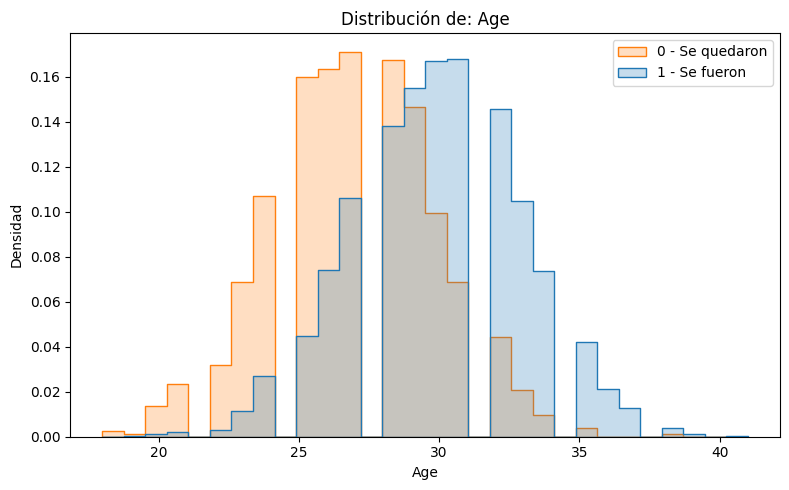

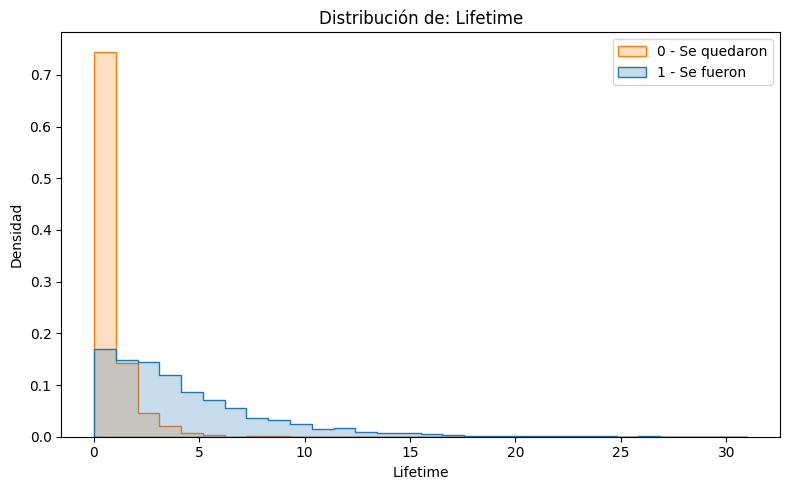

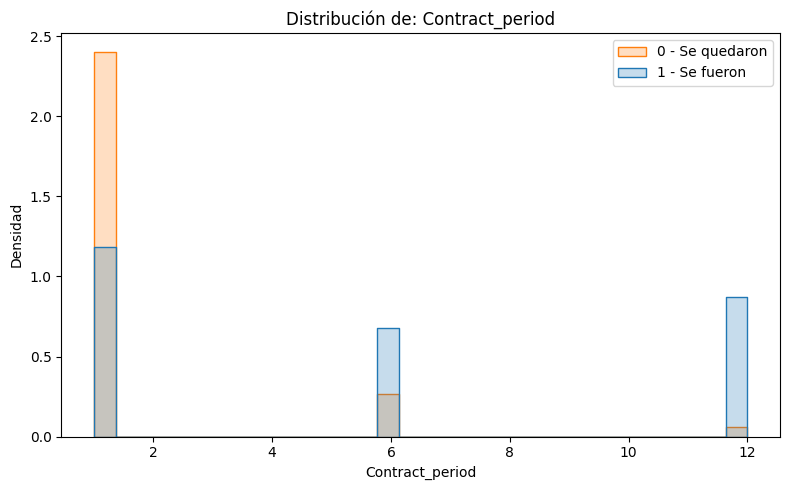

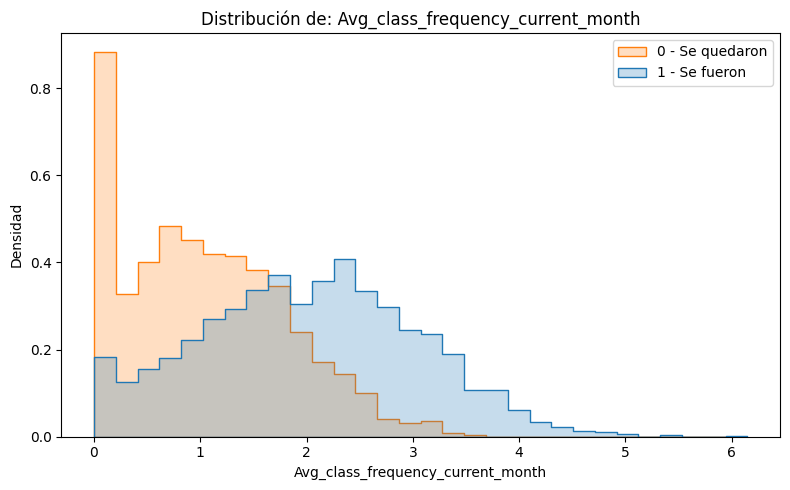

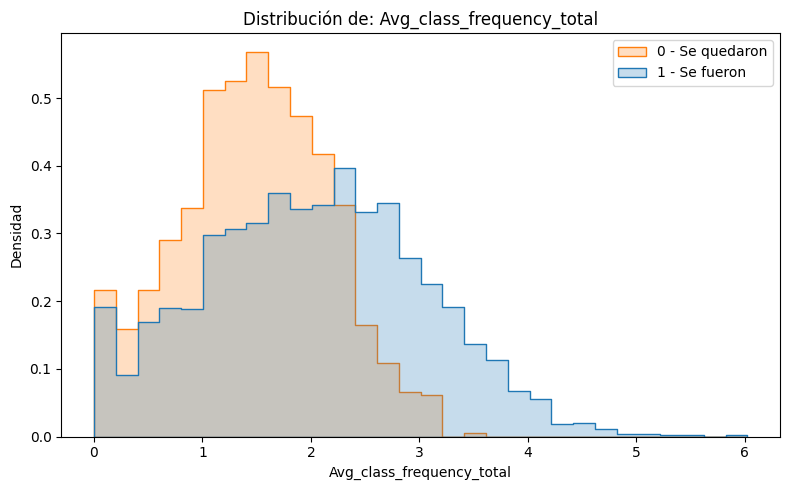

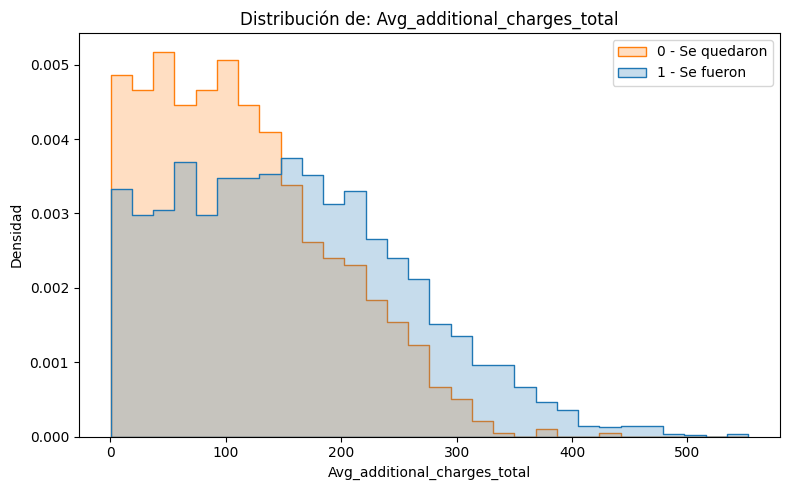

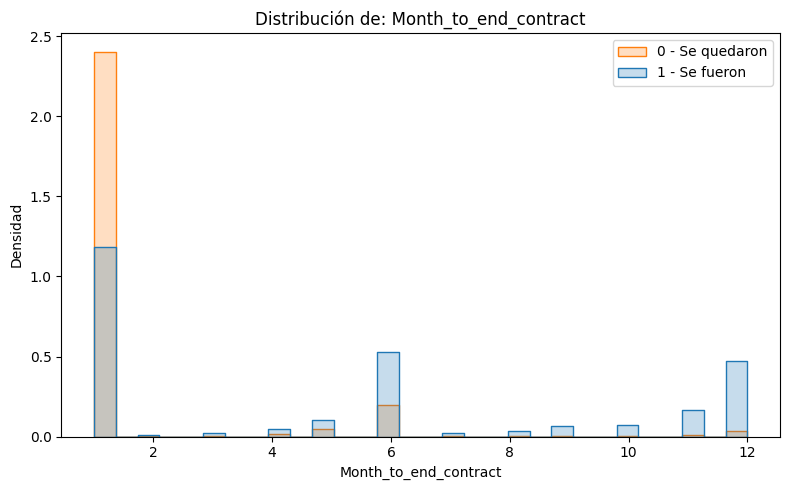

In [29]:
# Trazar histogramas de variables clave
variables_clave = ["Age", "Lifetime", "Contract_period", "Avg_class_frequency_current_month", "Avg_class_frequency_total", "Avg_additional_charges_total", "Month_to_end_contract"]

for var in variables_clave:
    plt.figure(figsize=(8,5))
    sns.histplot(data=gym, x=var, hue="Churn", bins=30, kde=False, element="step", stat="density", common_norm=False)
    plt.title(f"Distribución de: {var}")
    plt.xlabel(var)
    plt.ylabel("Densidad")
    plt.legend(labels=["0 - Se quedaron", "1 - Se fueron"])
    plt.tight_layout()
    plt.show()

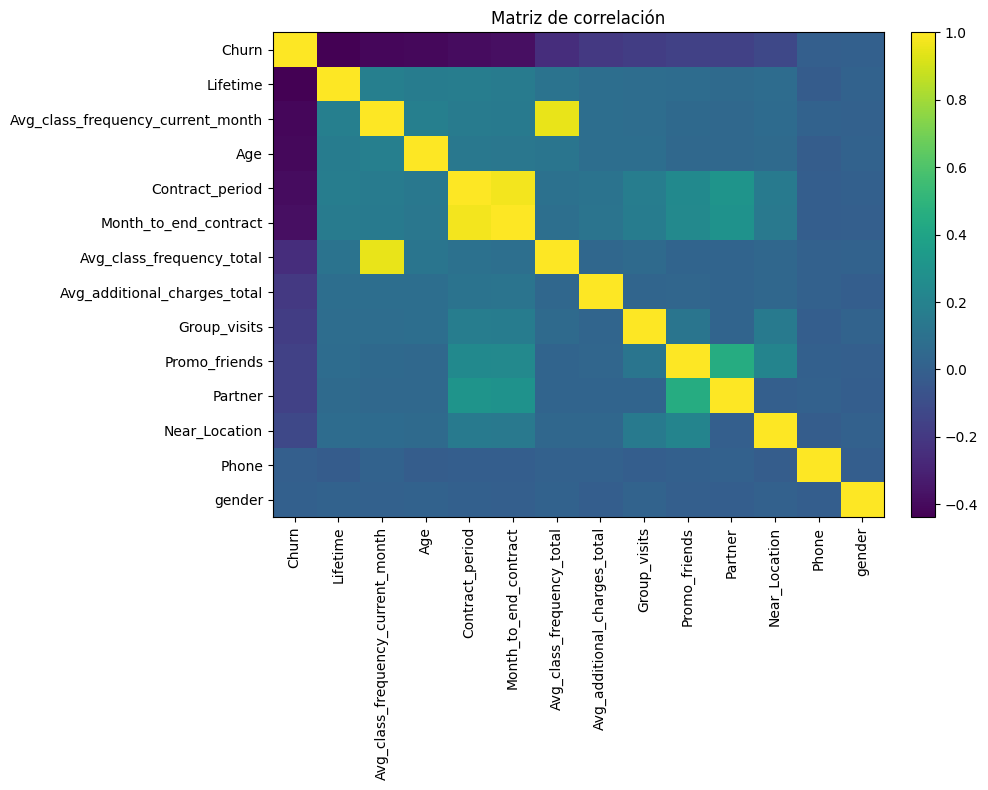

In [30]:
# Crar matriz de correlación
corr = gym.corr(numeric_only=True)

if 'Churn' in corr.columns:
    order = corr['Churn'].abs().sort_values(ascending=False).index.tolist()
    corr = corr.loc[order, order]

# Crear mapa de calor para concer la relación entre las características.
plt.figure(figsize=(10, 8))
im = plt.imshow(corr, aspect='auto')
plt.title("Matriz de correlación")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(np.arange(len(corr.index)), corr.index)
plt.tight_layout()
plt.show()

#### Objetivo #1.- Predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
- Esto lo podemos logar mediante el método predict_proba de los conjuntos de datos de entranamiento y prueba del modelo "LogisticRegression".
#### Objetivo #2.- Elaborar retratos de usuarios típicos.
- Esto lo podemos lograr mediante el emparejamiento de las variables "Lifetime" vs "Avg_class_frecuency_total" donde se podrá distinguier entre clientes fieles y constantes de los que entran y salen rápido.
- Esto lo podemos lograr mediante el emparejamiento de las variables "Contract_period" vs "Avg_class_frecuency_current_month" donde se podrá ver la diferencia entre los que hacen contratos largos que cumplen de los que asisten poco.
- El análisis de estos gráficos permitirán también apreciar perfiles claros tales como: el cliente fiel, el de contrato largo pero inactivo, el de contrato corto pero frecuente, etc.
#### Objetivo #3.- Analizar los factores que más impactan la pérdida.
- Esto lo podemos lograr mediante el emparejamiento de las variables sociales "group_visits", "promo_friends", "partner" y de conveniencia "near_location" donde se podrá analizar si el entorno social y la facilidad de acceso influyen en la permanencia.

In [31]:
# Construir modelo de clasificación binaria

# Separar características y target
X = gym.drop(['Churn'], axis=1)
y = gym['Churn']

# Crar grupos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

# Crear pipelines de los modelos 
pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, random_state=42))
])

pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenar modelos
pipe_logreg.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Obtener Predicciones
y_pred_logreg = pipe_logreg.predict(X_test)
y_pred_proba = pipe_logreg.predict_proba(X_test)[:,1] # Predecir probabilidad de pérdida (para el próximo mes) para cada cliente.
y_pred_forest = pipe_rf.predict(X_test)

# Presentar reporte de metricas
metrics_report(y_test, y_pred_logreg, "Logistic Regression")
metrics_report(y_test, y_pred_forest, "Random Forest")

print(classification_report(y_test, y_pred_logreg))

#7. Agregar las probabilidades como columna del dataframe
X_test['Churn_proba'] = y_pred_proba


=== Logistic Regression ===
Accuracy : 0.925
Precision: 0.880
Recall   : 0.830
F1-score : 0.854

=== Random Forest ===
Accuracy : 0.926
Precision: 0.884
Recall   : 0.830
F1-score : 0.856
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       588
           1       0.88      0.83      0.85       212

    accuracy                           0.93       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.93      0.92       800



En base a los datos provistos por los modelos, ambos rinden casi igual (> 90), sin embargo, el bosque aleatorio tiene ligeramente mejores valores en exactitud y precisión (menos falsos positivos) con el mismo recall.

Se elige el modelo de Random Forest como el más preciso en este caso .

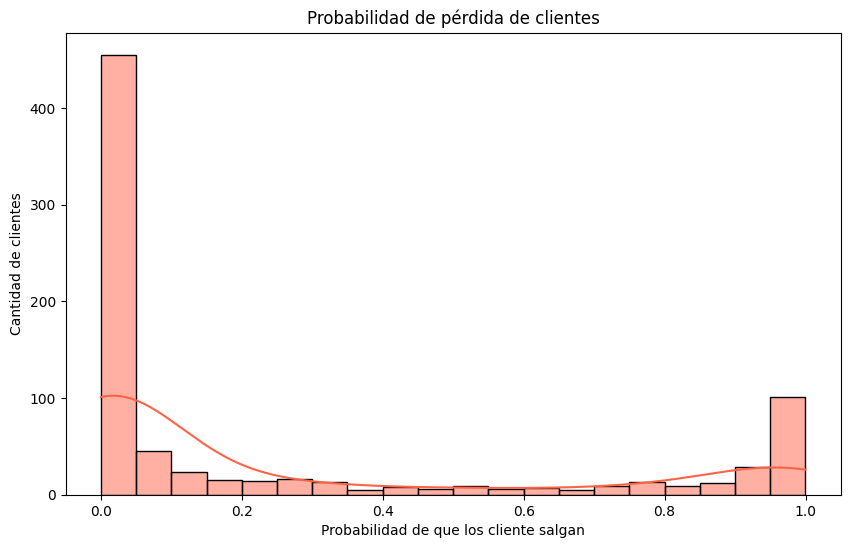

In [32]:
# Probabiliad de pérdida de clientes para el próximo mes.
plt.figure(figsize=(10,6))
sns.histplot(y_pred_proba, bins=20, kde=True, color="tomato")
plt.title("Probabilidad de pérdida de clientes")
plt.xlabel("Probabilidad de que los cliente salgan")
plt.ylabel("Cantidad de clientes")
plt.show()

### Interpretación:

**1. Mayoría de clientes con riesgo muy bajo.-** La barra más alta está pegada al 0.0; significa que la gran mayoría de clientes tienen probabilidad de abandonar el gimnasio casi nula; estos son clientes muy estables, de bajo riesgo.

**2. Pequeño grupo con riesgo muy alto.-** En la barra cercana a 1.0, hay un grupo mucho más reducido (de casi 100 clientes) con altísima probabilidad de irse; estos representan los clientes críticos que requieren atención inmediata.

**3. Muy pocos en zona intermedia.-** Entre 0.2 y 0.8 casi no hay clientes, esto se debe a que el modelo tiende a clasificar en extremos: o muy seguros de quedarse, o muy probables de irse.

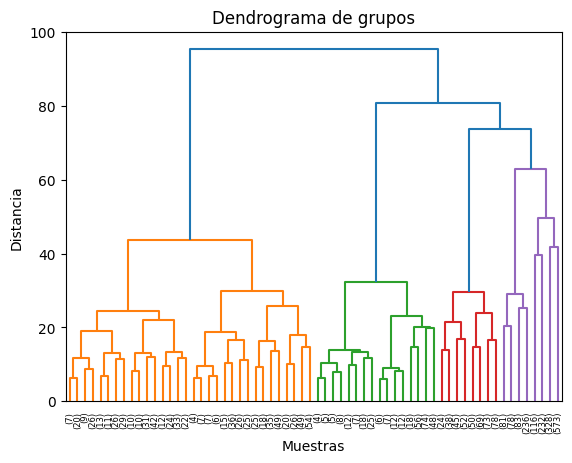

In [33]:
#------------------------ ESTANDARIZAR DATOS
scaler = StandardScaler() # Definir el modelo 
X_train_st = scaler.fit_transform(X_train) # Entrenar y Obtener el conjunto de entranamiento estandarizado
X_test_st = scaler.transform(X_test.drop(columns=['Churn_proba'])) # Obtener el conjunto de prueba estandarizado

# Crear la matriz de distancias
Z = linkage(X_train_st, method="ward")

# Graficar el dendrograma
plt.Figure(figsize=(15, 7))
dendrogram(Z, truncate_mode='level', p=5) #Mostrar solo los primeros 5 niveles.
plt.title("Dendrograma de grupos")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.show()


In [34]:
# Establecer el modelo con 5 clústeres y probar con 10 inicializaciones distintas para quedarse con la más estable
kmeans = KMeans(n_clusters=5, n_init= 10, random_state=42)

# Entrenar el modelo con los datos estandarizados
kmeans.fit(X_train_st)

# Obtener etiquetas de clúster para el conjunto de entrenamiento
train_labels = kmeans.labels_

# Predecir los clústers para el conjunto de prueba
test_labels = kmeans.predict(X_test_st)

# Agregar a qué clúster pertenece cada registro en ambos dataframes
X_train['cluster'] = train_labels
X_test['cluster'] = test_labels

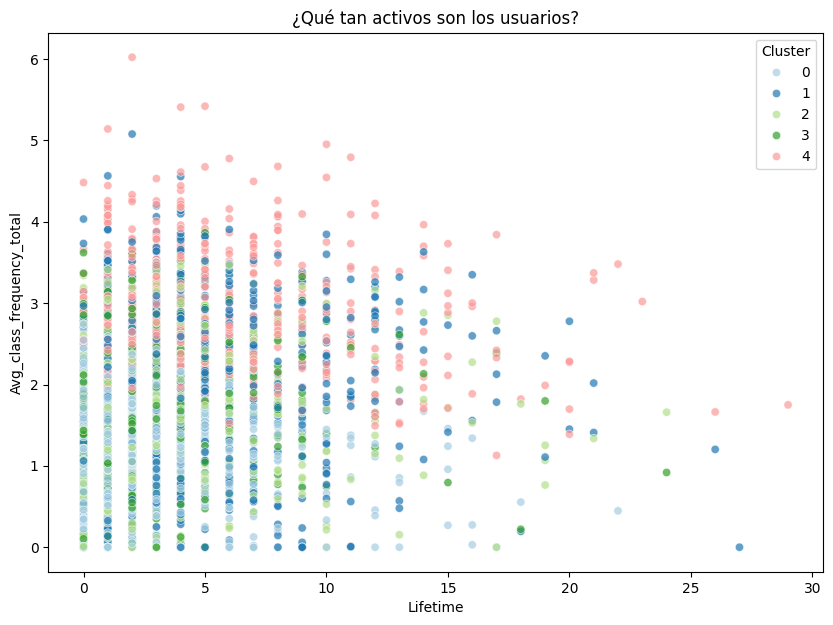

In [35]:
# Graficar clústers

# 1. Lifetime vs Avg_class_frequency_total
show_clusters_on_plot(
    X_train,
    "Lifetime",
    "Avg_class_frequency_total",
    train_labels,
    "¿Qué tan activos son los usuarios?")

### **Interpretación:**

- Se distinguen clústers con distinta combinación de tiempo de permanencia y frecuencia de clases.
- Hay grupos con poca permanencia y baja frecuencia (más vulnerables a irse) y otros con alta permanencia y alta frecuencia (clientes fieles y activos).
- Los clústers intermedios muestran que no todos los clientes antiguos son muy activos, lo cual marca perfiles diferenciados.

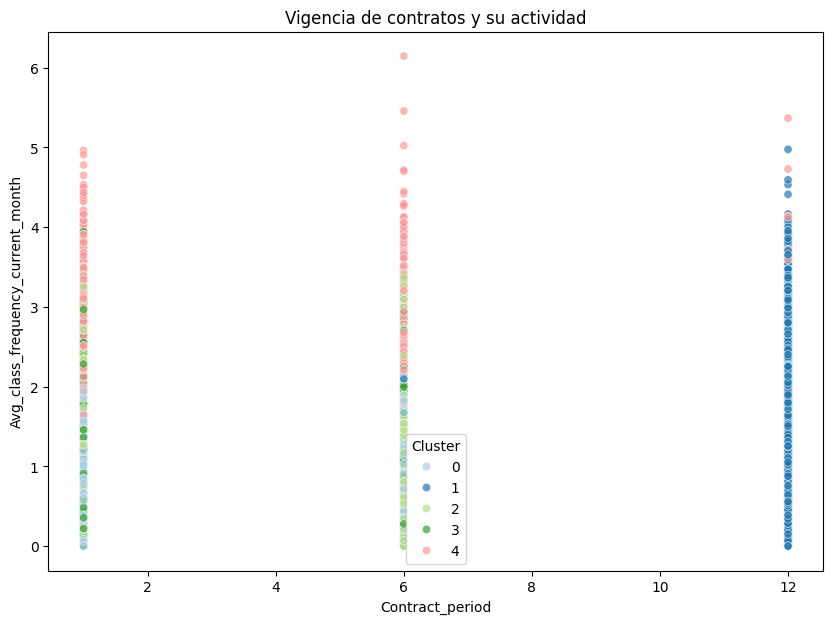

In [36]:
# 2. Contract_period vs Avg_class_frequency_current_month
show_clusters_on_plot(
    X_train,
    "Contract_period",
    "Avg_class_frequency_current_month",
    train_labels,
    "Vigencia de contratos y su actividad")

### **Interpretación:**

- Los períodos de contratación (1, 6 y 12 meses) son claramente identificados.
- Dentro de cada contrato, los clústeres separan clientes según su nivel de asistencia reciente.
- Esto muestra que no basta con tener contrato largo: hay clientes con 12 meses de contrato que van poco y otros que aprovechan mucho.

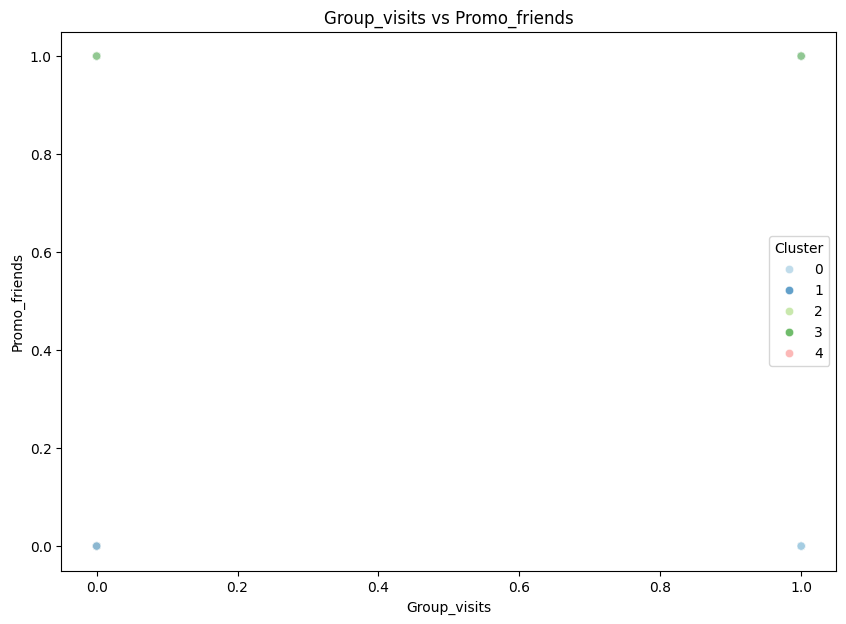

In [37]:
# 3. Group_visits vs Promo_friends
show_clusters_on_plot(
    X_train,
    "Group_visits",
    "Promo_friends",
    train_labels,
    "Group_visits vs Promo_friends")

### **Interpretación:**

- Los valores son binarios (0 o 1), por eso se ven solo en las esquinas del gráfico.
- Aun así, se aprecia que algunos clústeres agrupan clientes que sí vienen en grupo y traen amigos, frente a otros que no.
- Aunque simple, confirma que el factor social distingue subgrupos de clientes.

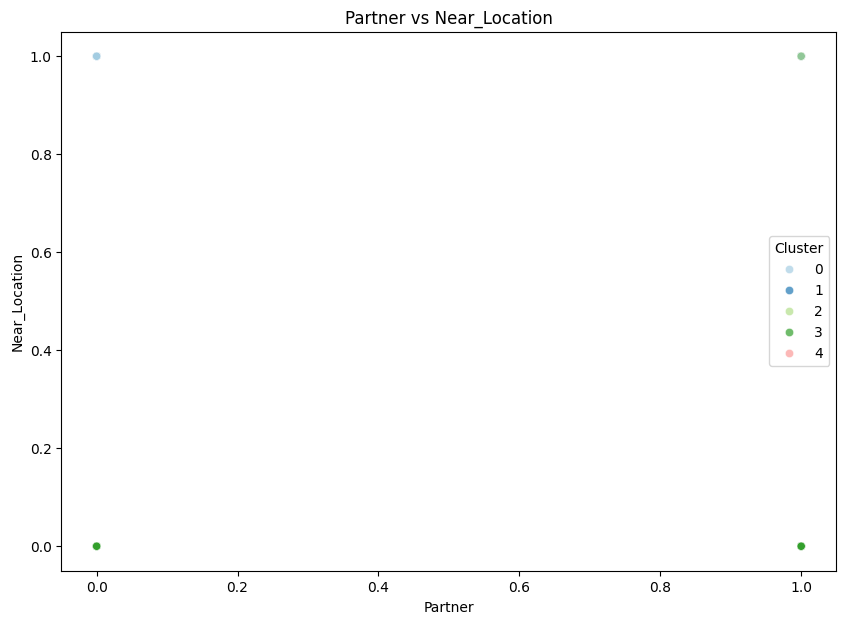

In [38]:
# 4. Partner vs Near_Location
show_clusters_on_plot(
   X_train,
    "Partner",
    "Near_Location",
    train_labels,
    "Partner vs Near_Location")

### **Interpretación:**

- Igual que el caso anterior (binarias), se ven en esquinas.
- Se distinguen clústeres de clientes que están cerca y con convenio vs. lejanos y sin convenio.
- Estos factores de conveniencia marcan segmentos que pueden tener distinta retención.

## Conclusiones
1. **La mayoría de los clientes son estables**:
   El modelo predice que la mayor parte tiene **muy baja probabilidad de irse**, lo que indica que existe una base sólida de usuarios leales.

2. **Existe un grupo reducido con alto riesgo de irse**:
   Se identificó un segmento con probabilidad cercana al **100% de abandono**, lo cual representa una pérdida casi segura si no se actúa.

3. **Factores más asociados a la fuga de clientes**:
   * **Frecuencia de asistencia**: los que disminuyen su participación, sobre todo en el último mes, tienen alta probabilidad de irse.
   * **Contrato**: clientes con periodos cortos son más propensos a la rotación.
   * **Factores sociales y conveniencia**: venir en grupo, traer amigos, convenios y cercanía reducen significativamente la pérdida.
   * **Edad y gasto adicional**: clientes un poco más mayores y los que consumen servicios extra muestran mayor fidelidad.

### a) Grupos objetivo identificados:
1. **Clientes fieles y activos**: alta permanencia, alta asistencia, contratos largos. Son la base estable, pueden aprovecharse para programas de recomendación
2. **Clientes en riesgo alto**: asistencia en caída, contratos cortos, sin convenios ni interacción social. Deben ser la prioridad en estrategias de retención.
3. **Clientes sociales**: usan promociones con amigos, vienen en grupo, están cerca del centro. Muy valiosos porque atraen y fidelizan más usuarios.

### b) Medidas para reducir la rotación:
1. **Monitorear asistencia mensual**: Crear alertas cuando un cliente baje su frecuencia y después actuar con llamadas o promociones personalizadas.
2. **Incentivar contratos largos**: Bonos o descuentos especiales al renovar por 6 o 12 meses.
3. **Promover interacción social**: Programas de “trae a un amigo”, actividades en grupo, alianzas con empresas locales.
4. **Beneficios adicionales**: Dar valor agregado (clases especiales, productos, descuentos en extras) para clientes que ya invierten más.

### c) Otros patrones observables:
* **Edad**: clientes más jóvenes tienden a rotar más, requieren estrategias distintas (ej. planes flexibles o actividades más dinámicas).
* **Cercanía al centro**: quienes viven cerca se mantienen más; podría explorarse programas de apoyo a clientes que viven lejos.
* **Segmentación clara de riesgo**: en el modelo no se observa una zona gris con alta relevancia, los clientes claramente se distinguen entre seguros o en riesgo.